In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [2]:
file_path = "../datasets/credit_risk_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### Performing EDA on the Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [4]:
# checking for missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
# checking for unique values in each column
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

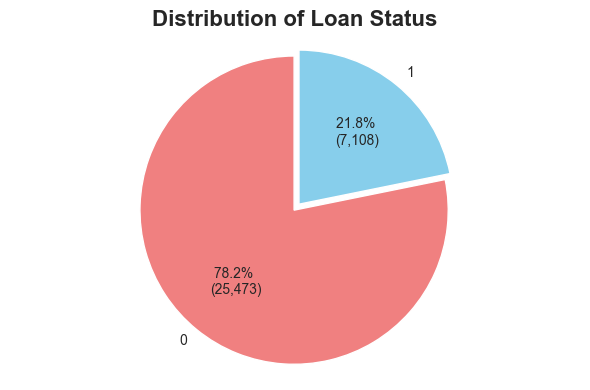

Loan Status Distribution:
0: 25473 (78.2%)
1: 7108 (21.8%)


In [6]:
# creating a pie chart for loan_status distribution
plt.figure(figsize=(6, 4))
loan_status_counts = df['loan_status'].value_counts()

# function to show both percentage and count
def autopct_format(pct):
    absolute = int(pct / 100. *len(df))
    return f'{pct:.1f}% \n({absolute:,})'

plt.pie(
    loan_status_counts.values, 
    labels=loan_status_counts.index, 
    autopct=autopct_format,
    startangle=90,
    colors=['lightcoral', 'skyblue'],
    explode=(0.05, 0)
)

plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# printing the actual counts for reference
print(f"Loan Status Distribution:")
for status, count in loan_status_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{status}: {count} ({percentage:.1f}%)")

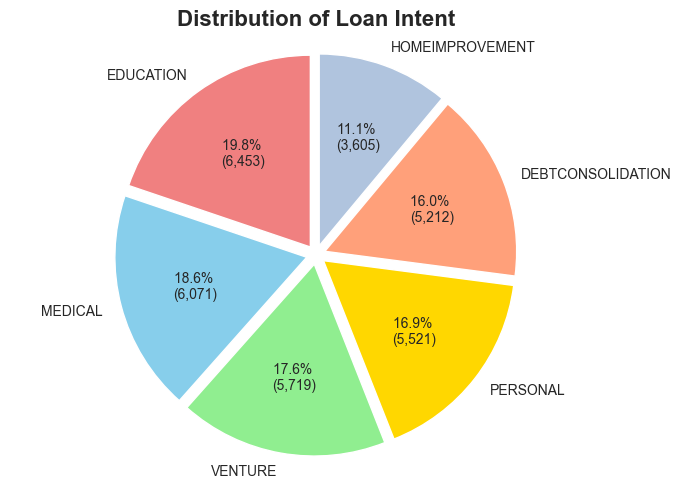

In [7]:
# creating a pie chart for loan_intent distribution
plt.figure(figsize=(7, 5))
loan_intent_counts = df['loan_intent'].value_counts()

def autopct_format_intent(pct):
    absolute = int(pct/100.*len(df))
    return f'{pct:.1f}% \n({absolute:,})'

colors = ['lightcoral', 'skyblue', 'lightgreen', 'gold', 'lightsalmon', 'lightsteelblue']

plt.pie(
    loan_intent_counts.values, 
    labels=loan_intent_counts.index, 
    autopct=autopct_format_intent,
    startangle=90,
    colors=colors[:len(loan_intent_counts)],
    explode=[0.05] * len(loan_intent_counts)
)

plt.title('Distribution of Loan Intent', fontsize=16, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

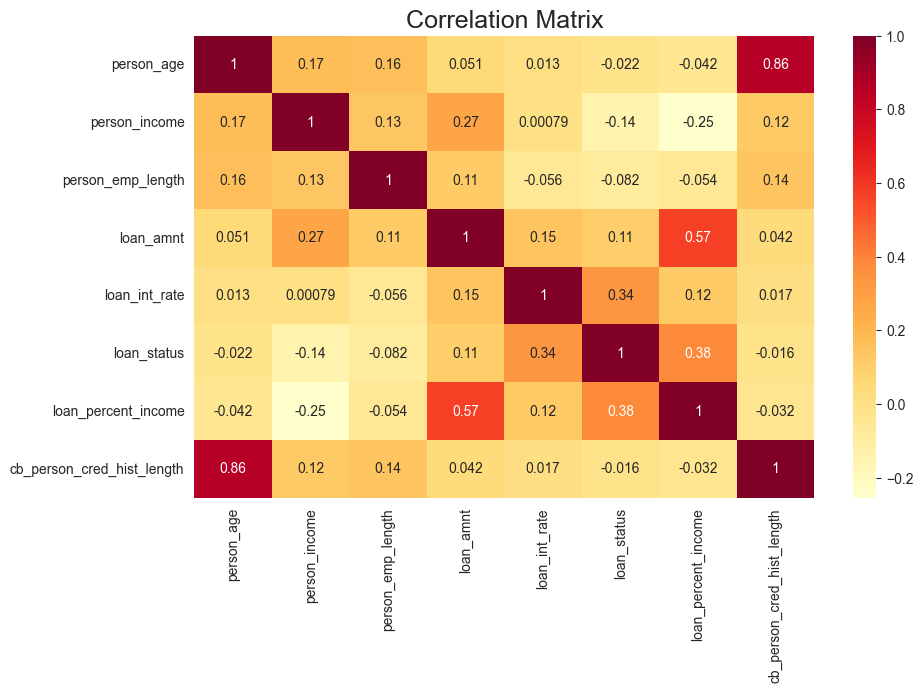

In [8]:
# visualizing the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix', fontsize=18)

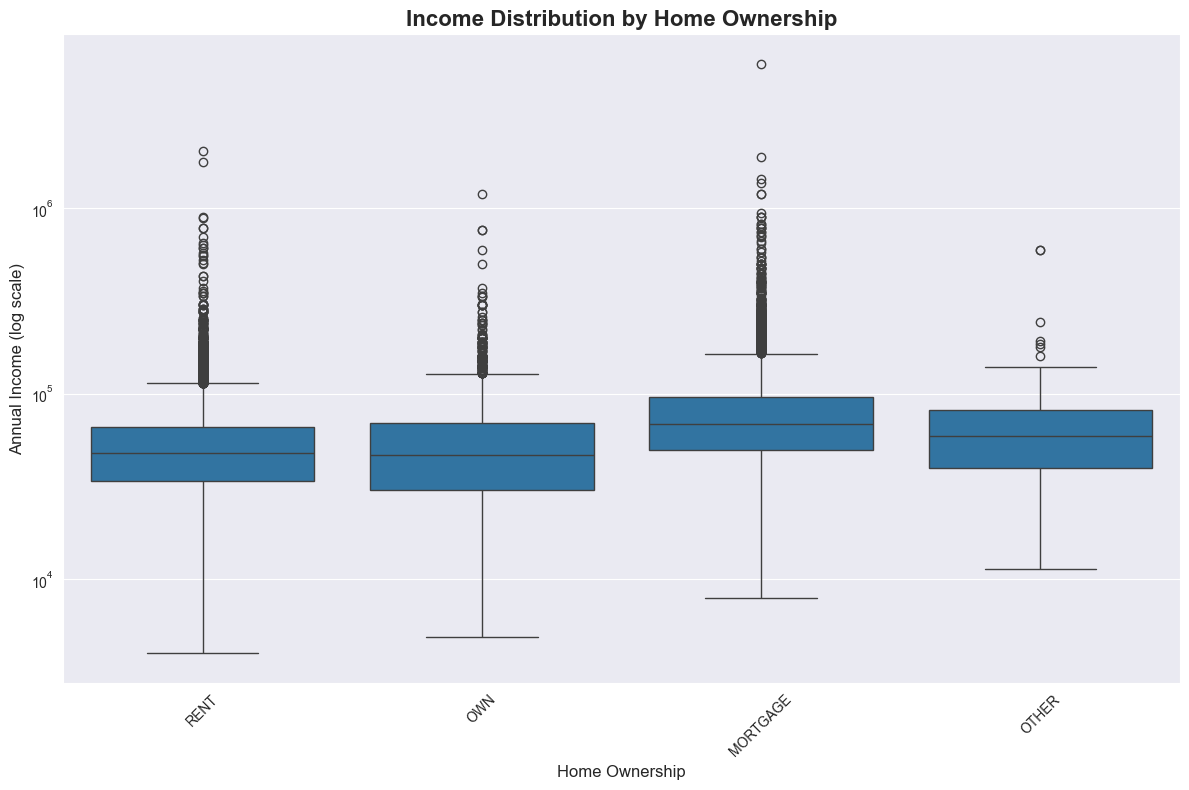


Income Summary by Home Ownership:

RENT:
  Median: $48,000.00
  Mean: $54,997.75
  Count: 16,446

OWN:
  Median: $47,000.00
  Mean: $57,834.81
  Count: 2,584

MORTGAGE:
  Median: $69,000.00
  Mean: $81,127.12
  Count: 13,444

OTHER:
  Median: $59,000.00
  Mean: $76,387.80
  Count: 107


In [9]:
# creating a box plot for income distribution by home ownership
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='person_home_ownership', y='person_income')

# setting y-axis to log scale for better visualization due to wide income range
plt.yscale('log')

plt.title('Income Distribution by Home Ownership', fontsize=16, fontweight='bold')
plt.xlabel('Home Ownership', fontsize=12)
plt.ylabel('Annual Income (log scale)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# printing summary statistics for each home ownership category
print("\nIncome Summary by Home Ownership:")
for ownership in df['person_home_ownership'].unique():
    subset = df[df['person_home_ownership'] == ownership]['person_income']
    print(f"\n{ownership}:")
    print(f"  Median: ${subset.median():,.2f}")
    print(f"  Mean: ${subset.mean():,.2f}")
    print(f"  Count: {len(subset):,}")

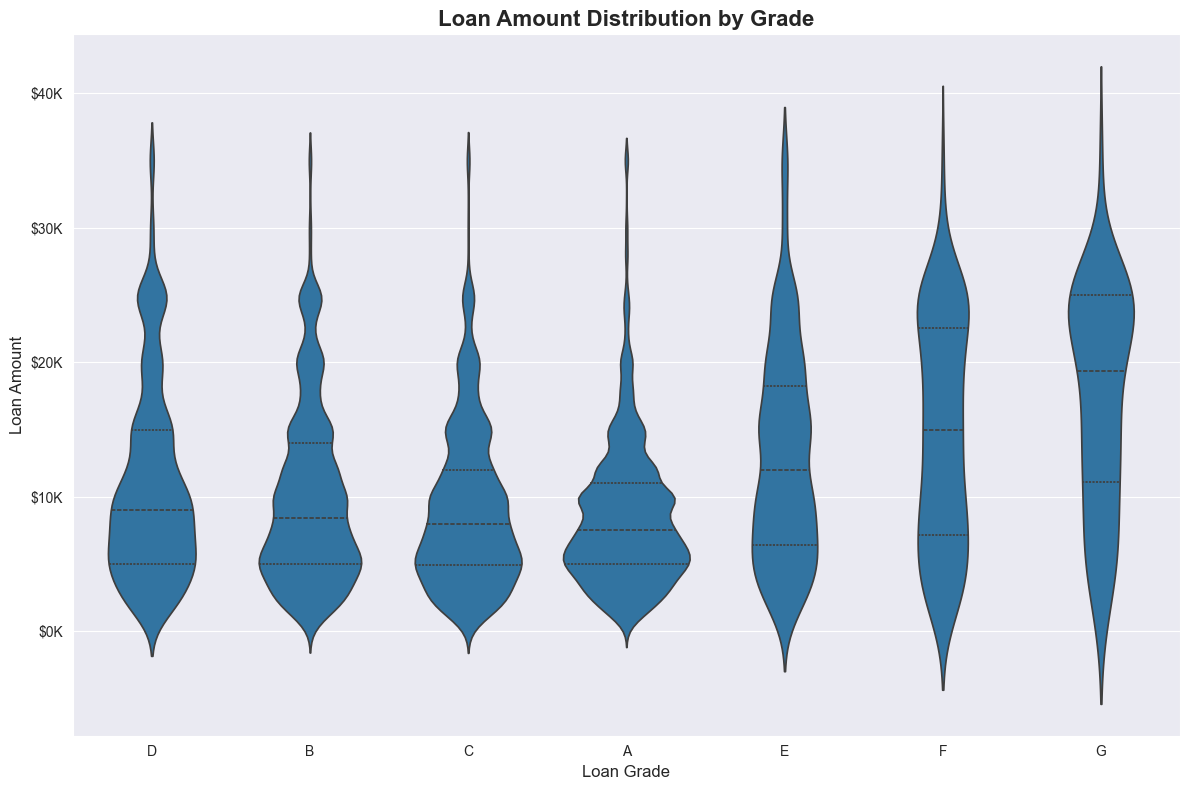


Loan Amount Summary by Grade:

Grade A:
  Median: $7,500.00
  Mean: $8,539.27
  Count: 10,777
  Range: $500.00 - $35,000.00

Grade B:
  Median: $8,400.00
  Mean: $9,995.48
  Count: 10,451
  Range: $500.00 - $35,000.00

Grade C:
  Median: $8,000.00
  Mean: $9,213.86
  Count: 6,458
  Range: $500.00 - $35,000.00

Grade D:
  Median: $9,000.00
  Mean: $10,849.24
  Count: 3,626
  Range: $1,000.00 - $35,000.00

Grade E:
  Median: $12,000.00
  Mean: $12,915.85
  Count: 964
  Range: $1,000.00 - $35,000.00

Grade F:
  Median: $15,000.00
  Mean: $14,717.32
  Count: 241
  Range: $1,200.00 - $35,000.00

Grade G:
  Median: $19,375.00
  Mean: $17,195.70
  Count: 64
  Range: $1,600.00 - $35,000.00


In [10]:
# creating a violin plot for loan amount distribution by loan grade
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='loan_grade', y='loan_amnt', inner='quartile')

plt.title('Loan Amount Distribution by Grade', fontsize=16, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)

# formatting y-axis to show values in thousands
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# printing summary statistics for each loan grade
print("\nLoan Amount Summary by Grade:")
for grade in sorted(df['loan_grade'].unique()):
    subset = df[df['loan_grade'] == grade]['loan_amnt']
    print(f"\nGrade {grade}:")
    print(f"  Median: ${subset.median():,.2f}")
    print(f"  Mean: ${subset.mean():,.2f}")
    print(f"  Count: {len(subset):,}")
    print(f"  Range: ${subset.min():,.2f} - ${subset.max():,.2f}")

In [11]:
# dropping null values since they are very few as compared to dataset size
df.dropna(axis=0, inplace=True)
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [12]:
df.shape

(28638, 12)

In [13]:
# checking the distribution of the target variable after dropping null values
df['loan_status'].value_counts()

loan_status
0    22435
1     6203
Name: count, dtype: int64

In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,28638.000000,2.863800e+04,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000
mean,27.727216,6.664937e+04,4.788672,9656.493121,11.039867,0.216600,0.169488,5.793736
std,6.310441,6.235645e+04,4.154627,6329.683361,3.229372,0.411935,0.106393,4.038483
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.595600e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: xlabel='person_age', ylabel='Count'>

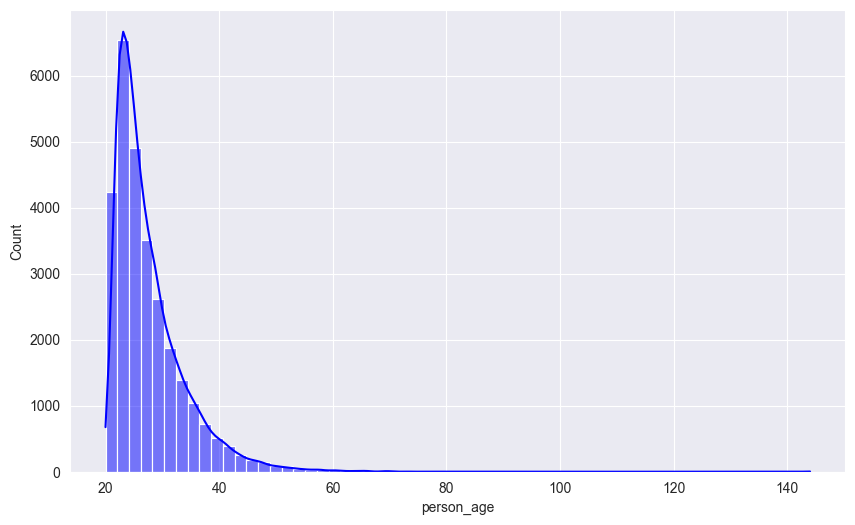

In [15]:
# checking the distribution of ages
plt.figure(figsize=(10, 6))
sns.histplot(df['person_age'], bins=60, kde=True, color='blue')

In [16]:
df['person_age'].value_counts().sort_index(ascending=False).head(10)

person_age
144    3
123    1
84     1
80     1
78     1
76     1
73     2
70     5
69     5
67     1
Name: count, dtype: int64

We see that there's some unknown values for age, such as 144. For this reason, it's safe to drop values where age of the person is greater than 80, as most likely they won't be applying for loan considering the age.

#### Feature Engineering

In [17]:
# dropping ages greater than 80 as they are outliers
df = df[df['person_age'] <= 80]
df.shape

(28633, 12)

In [18]:
# creating age groups
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[20, 26, 36, 46, 56, 66],
    labels=['20-25', '26-35', '36-45', '46-55', '56-65']
)

# creating income groups
df['income_group'] = pd.cut(
    df['person_income'],
    bins=[0, 25000, 50000, 75000, 100000, float('inf')],
    labels=['low', 'low-middle', 'middle', 'high-middle', 'high']
)

# creating loan amount groups
df['loan_amount_group'] = pd.cut(
    df['loan_amnt'],
    bins=[0, 5000, 10000, 15000, float('inf')],
    labels=['small', 'medium', 'large', 'very large']
)

##### Visualizations Supporting Feature Engineering Decisions

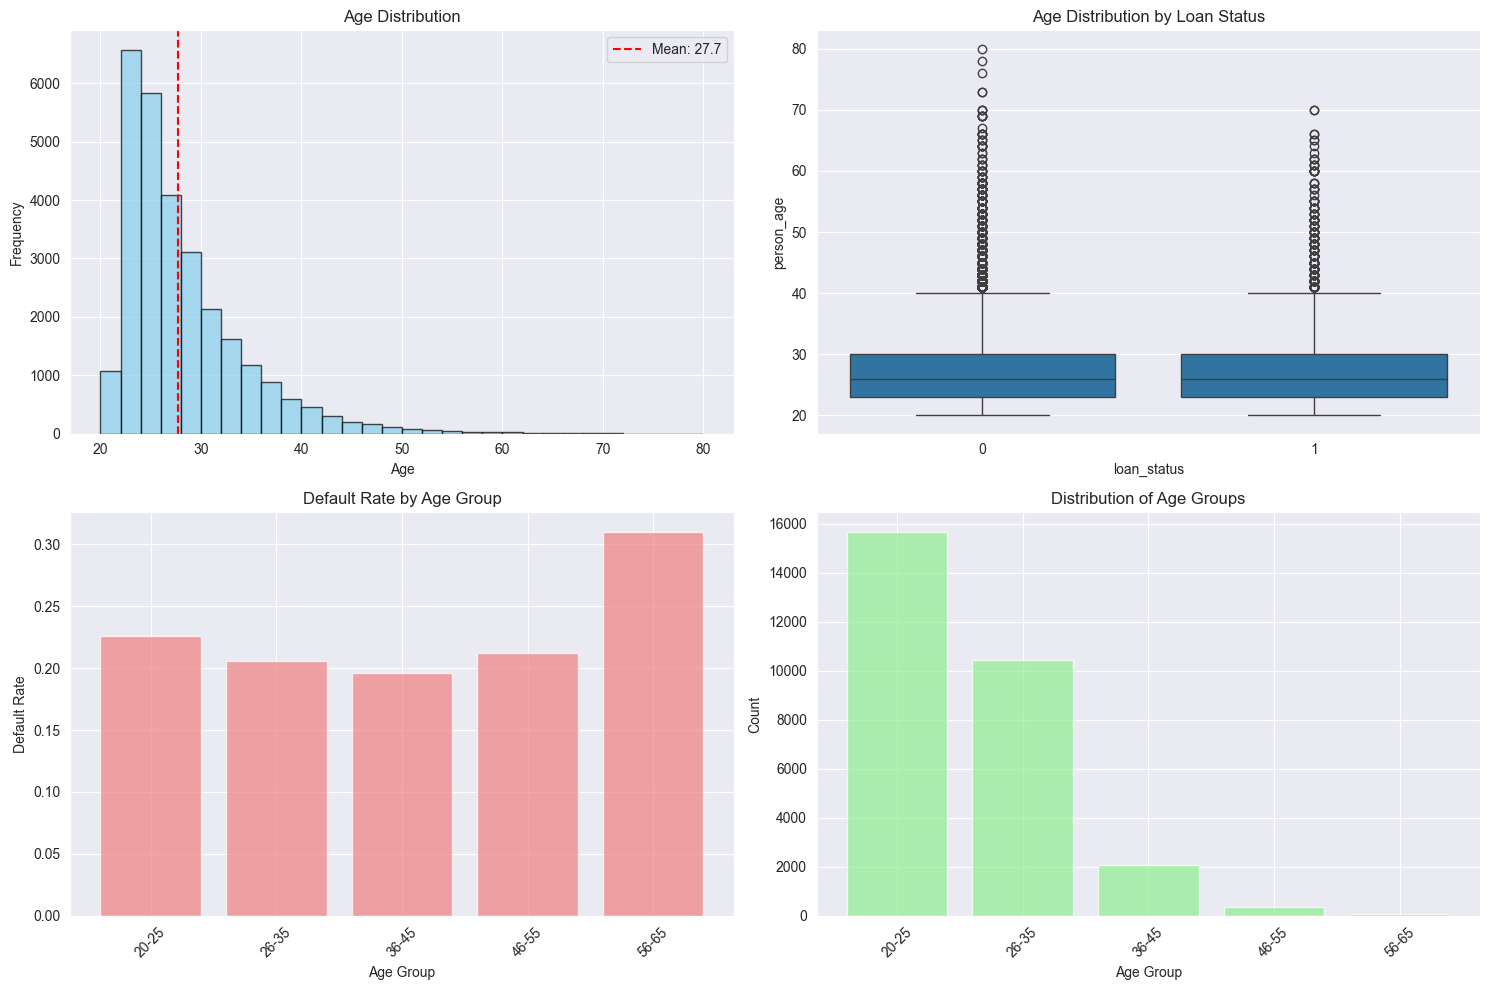

In [19]:
# 1. Age Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age histogram
axes[0,0].hist(df['person_age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['person_age'].mean(), color='red', linestyle='--', label=f'Mean: {df["person_age"].mean():.1f}')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Age vs Loan Status
sns.boxplot(data=df, x='loan_status', y='person_age', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Loan Status')

# Age groups vs Default Rate
age_default_rate = df.groupby('age_group')['loan_status'].mean()
axes[1,0].bar(age_default_rate.index, age_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Age Group')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Age group distribution
age_group_counts = df['age_group'].value_counts().sort_index()
axes[1,1].bar(age_group_counts.index, age_group_counts.values, color='lightgreen', alpha=0.7)
axes[1,1].set_title('Distribution of Age Groups')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

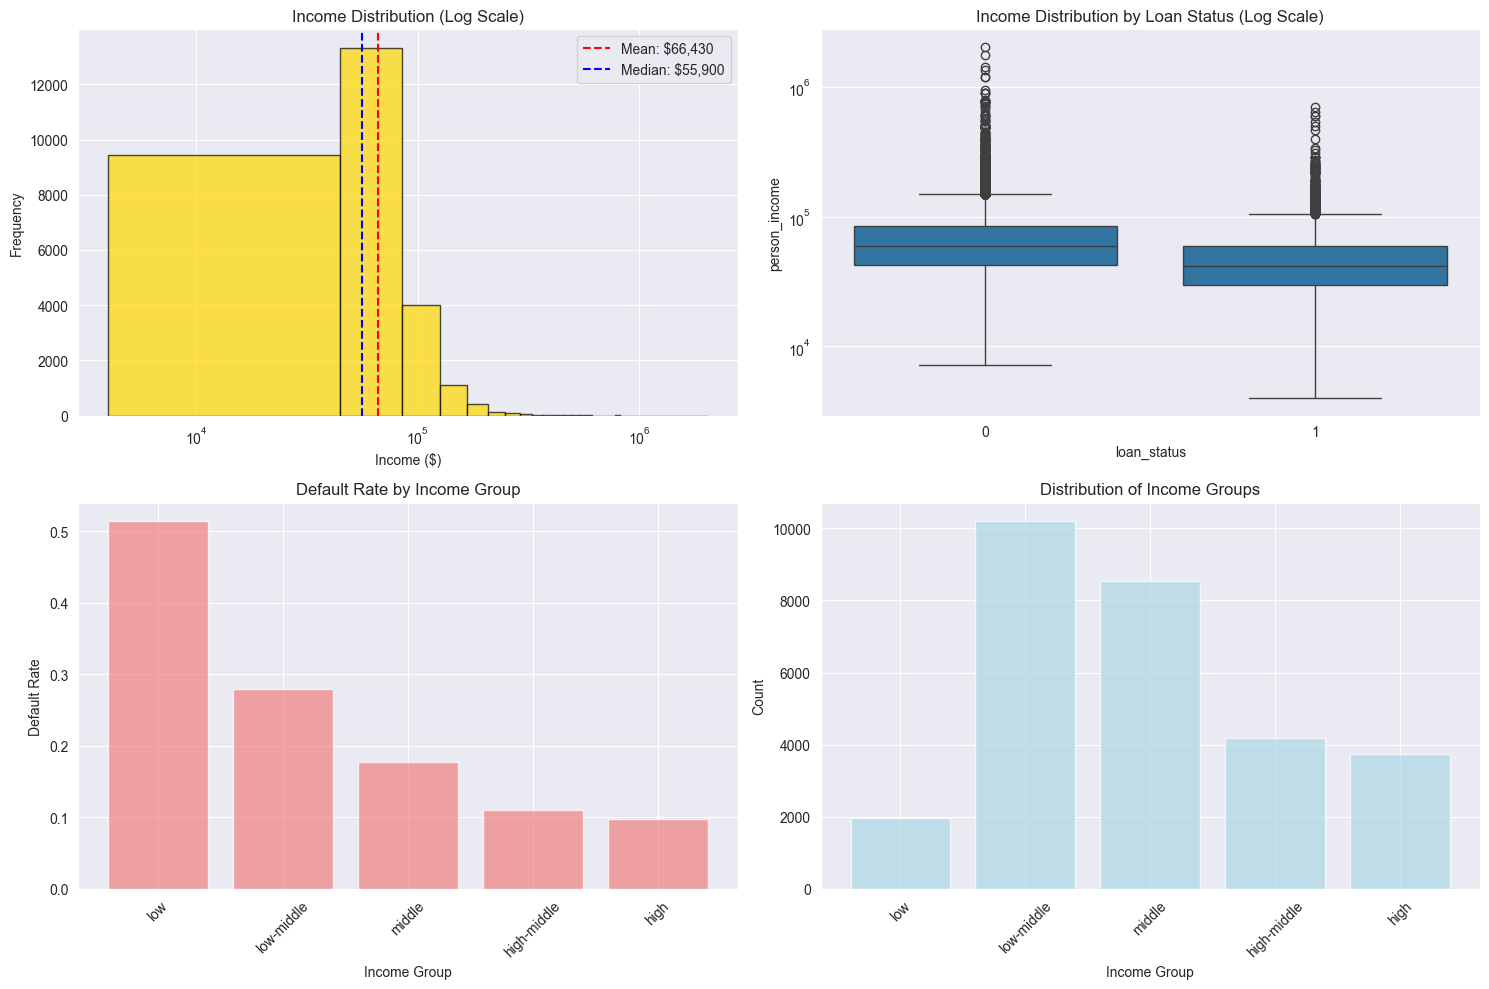

In [20]:
# 2. Income Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Income histogram (log scale)
axes[0,0].hist(df['person_income'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[0,0].set_xscale('log')
axes[0,0].axvline(df['person_income'].mean(), color='red', linestyle='--', label=f'Mean: ${df["person_income"].mean():,.0f}')
axes[0,0].axvline(df['person_income'].median(), color='blue', linestyle='--', label=f'Median: ${df["person_income"].median():,.0f}')
axes[0,0].set_title('Income Distribution (Log Scale)')
axes[0,0].set_xlabel('Income ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Income vs Loan Status
sns.boxplot(data=df, x='loan_status', y='person_income', ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_title('Income Distribution by Loan Status (Log Scale)')

# Income groups vs Default Rate
income_default_rate = df.groupby('income_group')['loan_status'].mean()
axes[1,0].bar(income_default_rate.index, income_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Income Group')
axes[1,0].set_xlabel('Income Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Income group distribution
income_group_counts = df['income_group'].value_counts().sort_index()
axes[1,1].bar(income_group_counts.index, income_group_counts.values, color='lightblue', alpha=0.7)
axes[1,1].set_title('Distribution of Income Groups')
axes[1,1].set_xlabel('Income Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

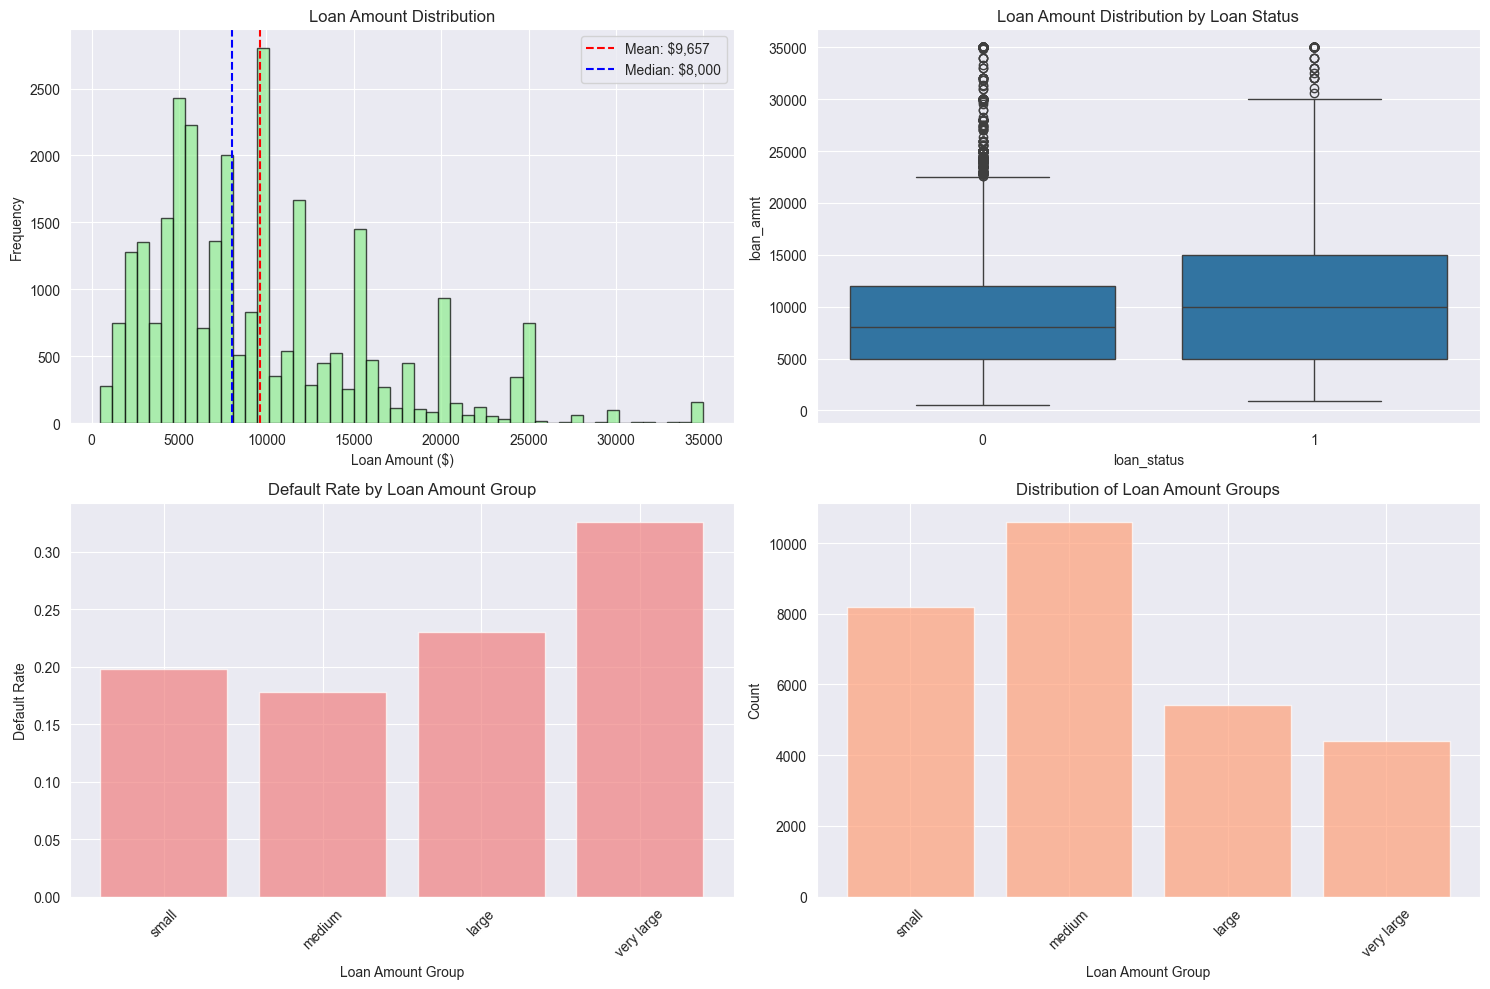

In [21]:
# 3. Loan Amount Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loan amount histogram
axes[0,0].hist(df['loan_amnt'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,0].axvline(df['loan_amnt'].mean(), color='red', linestyle='--', label=f'Mean: ${df["loan_amnt"].mean():,.0f}')
axes[0,0].axvline(df['loan_amnt'].median(), color='blue', linestyle='--', label=f'Median: ${df["loan_amnt"].median():,.0f}')
axes[0,0].set_title('Loan Amount Distribution')
axes[0,0].set_xlabel('Loan Amount ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Loan amount vs Loan Status
sns.boxplot(data=df, x='loan_status', y='loan_amnt', ax=axes[0,1])
axes[0,1].set_title('Loan Amount Distribution by Loan Status')

# Loan amount groups vs Default Rate
loan_default_rate = df.groupby('loan_amount_group')['loan_status'].mean()
axes[1,0].bar(loan_default_rate.index, loan_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Loan Amount Group')
axes[1,0].set_xlabel('Loan Amount Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Loan amount group distribution
loan_group_counts = df['loan_amount_group'].value_counts().sort_index()
axes[1,1].bar(loan_group_counts.index, loan_group_counts.values, color='lightsalmon', alpha=0.7)
axes[1,1].set_title('Distribution of Loan Amount Groups')
axes[1,1].set_xlabel('Loan Amount Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Statistical Validation of Feature Engineering Decisions:

1. AGE GROUPS:
   - Natural breaks appear around life stages (young adults, middle-aged, etc.)
   - Default rates vary significantly across age groups
   - 20-25: 15,668 records, 22.6% default rate
   - 26-35: 10,422 records, 20.6% default rate
   - 36-45: 2,054 records, 19.6% default rate
   - 46-55: 372 records, 21.2% default rate
   - 56-65: 87 records, 31.0% default rate

2. INCOME GROUPS:
   - Based on income quantiles and economic classifications
   - Clear inverse relationship with default rates
   - low: $4,000-$25,000, 51.4% default rate
   - low-middle: $25,040-$50,000, 28.0% default rate
   - middle: $50,004-$75,000, 17.7% default rate
   - high-middle: $75,127-$100,000, 11.0% default rate
   - high: $100,010-$2,039,784, 9.8% default rate

3. LOAN AMOUNT GROUPS:
   - Based on loan size categories and risk assessment
   - Relationship with default rates for risk profiling
   - small: $500-$5,000, 19.8% default rate
   

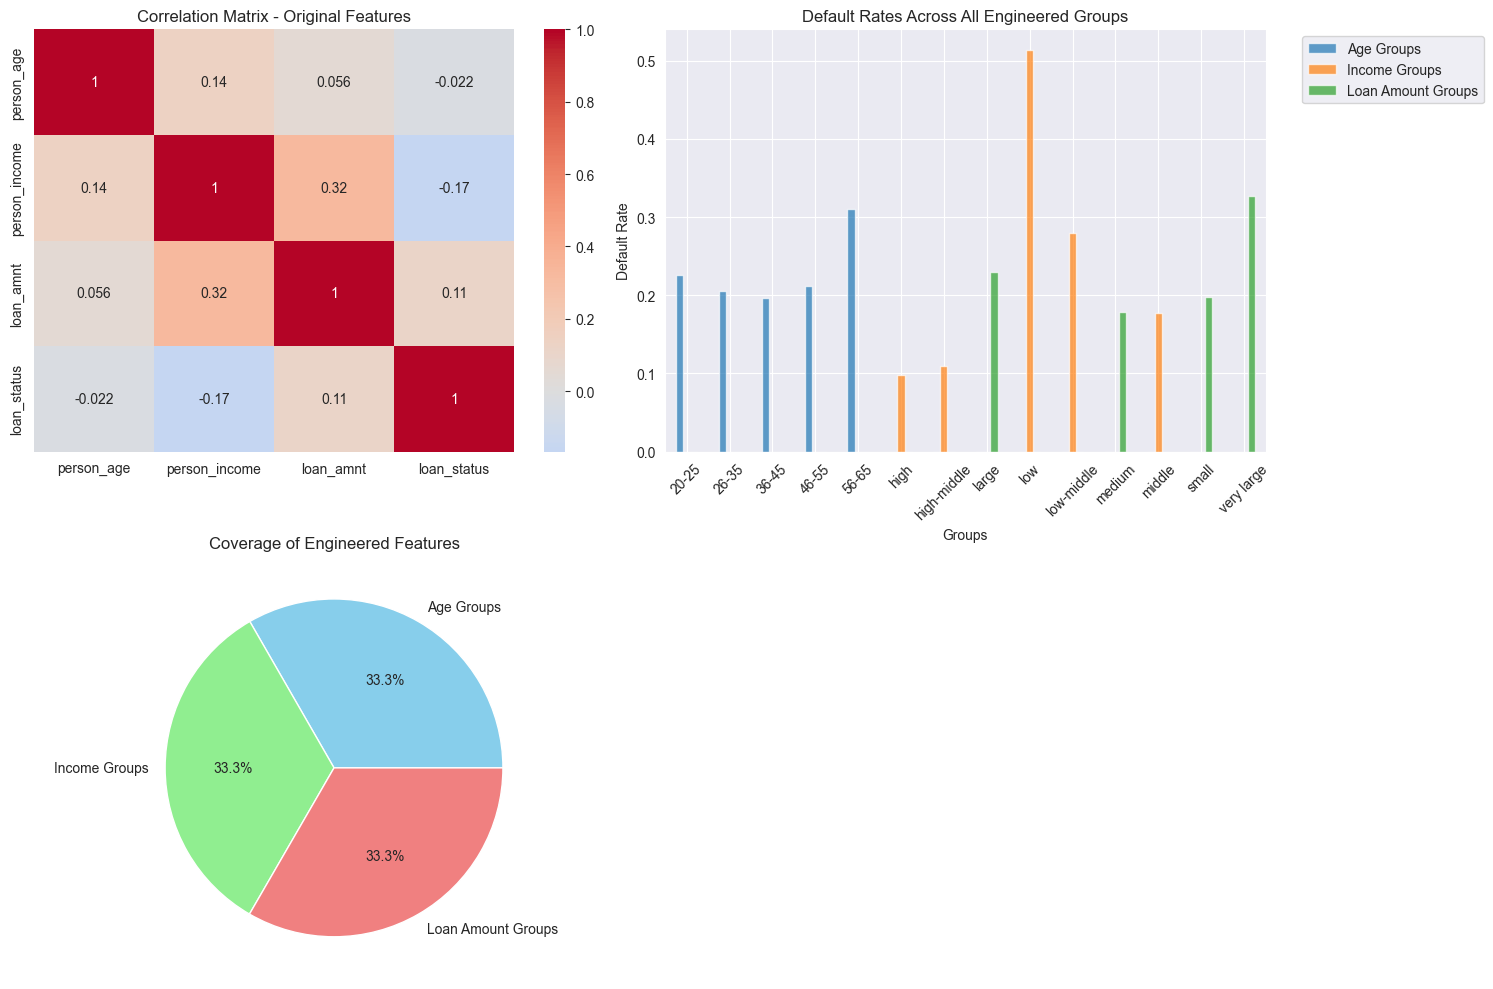

In [22]:
# 4. Summary Analysis - Validation of Feature Engineering
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Correlation heatmap of original vs engineered features
correlation_features = ['person_age', 'person_income', 'loan_amnt', 'loan_status']
corr_matrix = df[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix - Original Features')

# Default rates by all groups - comparison
group_default_rates = pd.DataFrame({
    'Age Groups': df.groupby('age_group')['loan_status'].mean(),
    'Income Groups': df.groupby('income_group')['loan_status'].mean(),
    'Loan Amount Groups': df.groupby('loan_amount_group')['loan_status'].mean()
})

group_default_rates.plot(kind='bar', ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Default Rates Across All Engineered Groups')
axes[0,1].set_xlabel('Groups')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)

# Distribution of records across groups
axes[1,0].pie([len(df[df['age_group'].notna()]), 
               len(df[df['income_group'].notna()]), 
               len(df[df['loan_amount_group'].notna()])], 
              labels=['Age Groups', 'Income Groups', 'Loan Amount Groups'], 
              autopct='%1.1f%%', 
              colors=['skyblue', 'lightgreen', 'lightcoral'])
axes[1,0].set_title('Coverage of Engineered Features')

# Statistical summary of groupings
print("Statistical Validation of Feature Engineering Decisions:\n")

print("1. AGE GROUPS:")
print("   - Natural breaks appear around life stages (young adults, middle-aged, etc.)")
print("   - Default rates vary significantly across age groups")
for group in df['age_group'].cat.categories:
    group_data = df[df['age_group'] == group]
    default_rate = group_data['loan_status'].mean()
    print(f"   - {group}: {len(group_data):,} records, {default_rate:.1%} default rate")

print("\n2. INCOME GROUPS:")
print("   - Based on income quantiles and economic classifications")
print("   - Clear inverse relationship with default rates")
for group in df['income_group'].cat.categories:
    group_data = df[df['income_group'] == group]
    default_rate = group_data['loan_status'].mean()
    income_range = group_data['person_income'].agg(['min', 'max'])
    print(f"   - {group}: ${income_range['min']:,.0f}-${income_range['max']:,.0f}, {default_rate:.1%} default rate")

print("\n3. LOAN AMOUNT GROUPS:")
print("   - Based on loan size categories and risk assessment")
print("   - Relationship with default rates for risk profiling")
for group in df['loan_amount_group'].cat.categories:
    group_data = df[df['loan_amount_group'] == group]
    default_rate = group_data['loan_status'].mean()
    amount_range = group_data['loan_amnt'].agg(['min', 'max'])
    print(f"   - {group}: ${amount_range['min']:,.0f}-${amount_range['max']:,.0f}, {default_rate:.1%} default rate")

# Remove the unused subplot
axes[1,1].remove()

plt.tight_layout()
plt.show()

In [23]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group,income_group,loan_amount_group
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,20-25,middle,very large
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,20-25,low,small
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,20-25,low,medium
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,20-25,middle,very large
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,20-25,middle,very large


In [24]:
# checking the distribution of home ownership
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        14549
MORTGAGE    11798
OWN          2192
OTHER          94
Name: count, dtype: int64

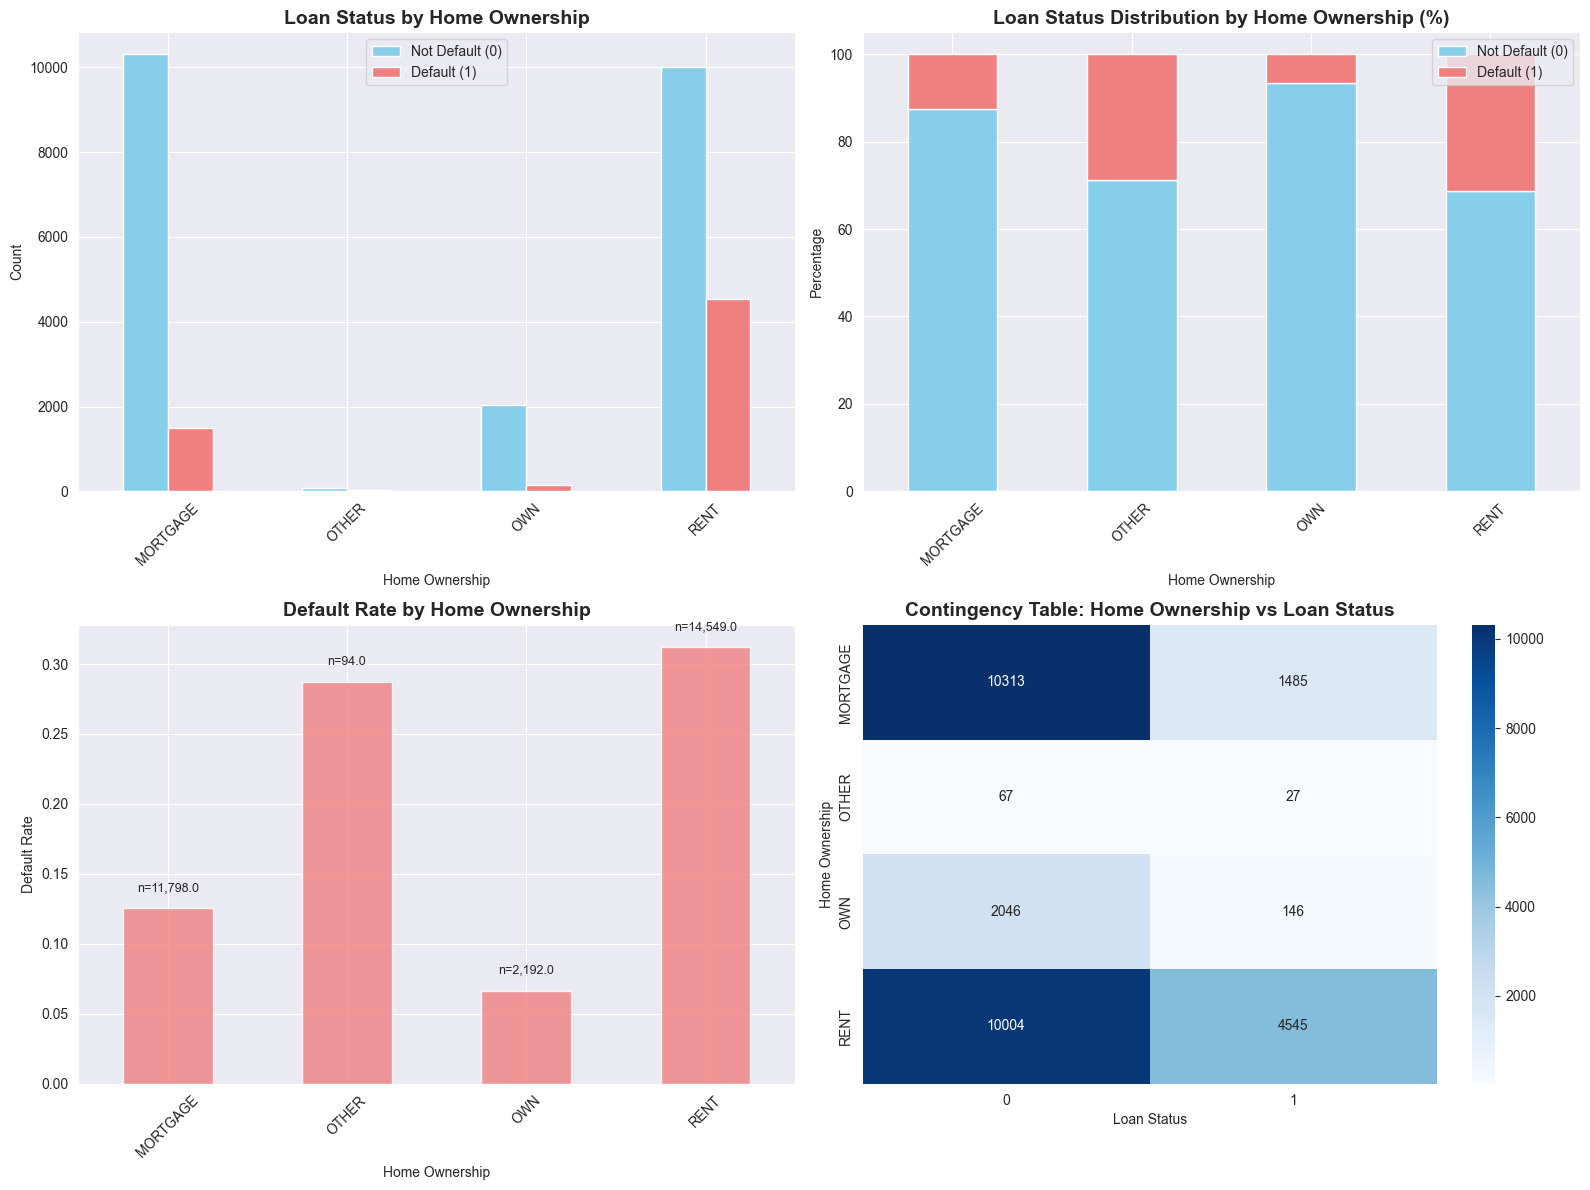

Detailed Analysis: Home Ownership vs Loan Status


RENT:
  Total Loans: 14,549
  Defaults: 4,545 (31.24%)
  Non-Defaults: 10,004 (68.76%)

OWN:
  Total Loans: 2,192
  Defaults: 146 (6.66%)
  Non-Defaults: 2,046 (93.34%)

MORTGAGE:
  Total Loans: 11,798
  Defaults: 1,485 (12.59%)
  Non-Defaults: 10,313 (87.41%)

OTHER:
  Total Loans: 94
  Defaults: 27 (28.72%)
  Non-Defaults: 67 (71.28%)

Chi-square Test for Independence:
  Chi-square statistic: 1652.3447
  p-value: 0.000000
  Degrees of freedom: 3
  Significant relationship: Yes (α = 0.05)


In [25]:
# analyzing the relationship between home ownership and loan status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grouped Bar Chart
home_loan_crosstab = pd.crosstab(df['person_home_ownership'], df['loan_status'])
home_loan_crosstab.plot(kind='bar', ax=axes[0,0], color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Loan Status by Home Ownership', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Home Ownership')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['Not Default (0)', 'Default (1)'])
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Stacked Percentage Bar Chart
home_loan_pct = pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index') * 100
home_loan_pct.plot(kind='bar', stacked=True, ax=axes[0,1], color=['skyblue', 'lightcoral'])
axes[0,1].set_title('Loan Status Distribution by Home Ownership (%)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Home Ownership')
axes[0,1].set_ylabel('Percentage')
axes[0,1].legend(['Not Default (0)', 'Default (1)'])
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Default Rate by Home Ownership
default_rates_by_home = df.groupby('person_home_ownership')['loan_status'].agg(['mean', 'count'])
default_rates_by_home['mean'].plot(kind='bar', ax=axes[1,0], color='lightcoral', alpha=0.8)
axes[1,0].set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Home Ownership')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (ownership, row) in enumerate(default_rates_by_home.iterrows()):
    axes[1,0].text(i, row['mean'] + 0.01, f'n={row["count"]:,}', 
                   ha='center', va='bottom', fontsize=9)

# 4. Heatmap of contingency table
sns.heatmap(home_loan_crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Contingency Table: Home Ownership vs Loan Status', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Loan Status')
axes[1,1].set_ylabel('Home Ownership')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Detailed Analysis: Home Ownership vs Loan Status\n")
print("="*60)

for ownership in df['person_home_ownership'].unique():
    subset = df[df['person_home_ownership'] == ownership]
    total_loans = len(subset)
    defaults = sum(subset['loan_status'])
    non_defaults = total_loans - defaults
    default_rate = defaults / total_loans
    
    print(f"\n{ownership}:")
    print(f"  Total Loans: {total_loans:,}")
    print(f"  Defaults: {defaults:,} ({default_rate:.2%})")
    print(f"  Non-Defaults: {non_defaults:,} ({(1-default_rate):.2%})")

# Statistical significance test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(home_loan_crosstab)
print(f"\n{'='*60}")
print(f"Chi-square Test for Independence:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Degrees of freedom: {dof}")
print(f"  Significant relationship: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

In [26]:
# creating loan-to-income ratio
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']

# creating loan-to-employment length ratio
df['loan_to_emp_length_ratio'] =  df['person_emp_length']/ df['loan_amnt'] 

# creating interest rate-to-loan amount ratio
df['int_rate_to_loan_amt_ratio'] = df['loan_int_rate'] / df['loan_amnt']

In [27]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'age_group',
       'income_group', 'loan_amount_group', 'loan_to_income_ratio',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio'],
      dtype='str')

In [28]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
count,28633.000000,2.863300e+04,28633.00000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000
mean,27.709741,6.642964e+04,4.78867,9656.565851,11.039841,0.216638,0.169503,5.792757,0.169863,0.000767,0.001866
std,6.163130,5.155164e+04,4.15470,6329.755492,3.229529,0.411961,0.106389,4.035676,0.106664,0.001077,0.001868
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000,0.001282,0.000000,0.000200
25%,23.000000,3.945600e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000,0.089286,0.000188,0.000792
50%,26.000000,5.590000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.147059,0.000455,0.001273
75%,30.000000,8.000000e+04,7.00000,12500.000000,13.480000,0.000000,0.230000,8.000000,0.227907,0.000941,0.002173
max,80.000000,2.039784e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000,0.830000,0.021000,0.022820


#### Splitting the Data into training and testing sets

In [29]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (22906, 17)
Testing set shape: (5727, 17)


In [31]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 22906 entries, 5754 to 26896
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  22906 non-null  int64   
 1   person_income               22906 non-null  int64   
 2   person_home_ownership       22906 non-null  str     
 3   person_emp_length           22906 non-null  float64 
 4   loan_intent                 22906 non-null  str     
 5   loan_grade                  22906 non-null  str     
 6   loan_amnt                   22906 non-null  int64   
 7   loan_int_rate               22906 non-null  float64 
 8   loan_percent_income         22906 non-null  float64 
 9   cb_person_default_on_file   22906 non-null  str     
 10  cb_person_cred_hist_length  22906 non-null  int64   
 11  age_group                   22880 non-null  category
 12  income_group                22906 non-null  category
 13  loan_amount_group           2

In [32]:
# specifying categorical and numerical columns
categorical_cols = X.select_dtypes(include=['str', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [33]:
categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'age_group', 'income_group',
       'loan_amount_group'],
      dtype='str')

In [34]:
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio'],
      dtype='str')

In [35]:
# encoding categorical variables using one-hot encoding
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
one_hot_encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [36]:
one_hot_encoder.categories_

[array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object),
 array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
        'PERSONAL', 'VENTURE'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object),
 array(['N', 'Y'], dtype=object),
 array(['20-25', '26-35', '36-45', '46-55', '56-65', nan], dtype=object),
 array(['high', 'high-middle', 'low', 'low-middle', 'middle'], dtype=object),
 array(['large', 'medium', 'small', 'very large'], dtype=object)]

In [37]:
# transform categorical columns
encoded_col_names = one_hot_encoder.get_feature_names_out(categorical_cols)

X_train_cat_ohe = pd.DataFrame(
    one_hot_encoder.transform(X_train[categorical_cols]),
    columns=encoded_col_names,
    index=X_train.index
)

X_test_cat_ohe = pd.DataFrame(
    one_hot_encoder.transform(X_test[categorical_cols]),
    columns=encoded_col_names,
    index=X_test.index
)

# combining numerical + encoded categorical columns
X_train = pd.concat([X_train[numerical_cols], X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test[numerical_cols], X_test_cat_ohe], axis=1)

In [38]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',
       'age_group_20-25', 'age_group_26-35', 'age_group_36-45',
       'age_group_46-55', 'age_group_56-65', 'age_group_nan',
       'income_group_high', 'income_group_high-middle', 'income_group_low',
       'income_group_low-middle', 'income_group

In [39]:
X_train.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,...,age_group_nan,income_group_high,income_group_high-middle,income_group_low,income_group_low-middle,income_group_middle,loan_amount_group_large,loan_amount_group_medium,loan_amount_group_small,loan_amount_group_very large
5754,26,30000,3.0,5400,10.00,0.18,4,0.180000,0.000556,0.001852,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
20397,34,45000,2.0,4500,16.95,0.10,10,0.100000,0.000444,0.003767,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14551,25,110000,1.0,10000,12.69,0.09,3,0.090909,0.000100,0.001269,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5439,23,56016,4.0,5000,15.13,0.09,3,0.089260,0.000800,0.003026,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6632,26,45928,5.0,6000,7.90,0.13,4,0.130639,0.000833,0.001317,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [40]:
# scaling numerical features using standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [41]:
# checking the distribution of numerical features after scaling
X_train.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,...,age_group_nan,income_group_high,income_group_high-middle,income_group_low,income_group_low-middle,income_group_middle,loan_amount_group_large,loan_amount_group_medium,loan_amount_group_small,loan_amount_group_very large
count,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,...,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000
mean,1.910828e-16,6.421127e-17,6.576227e-17,5.707669e-17,1.060882e-16,7.010506e-17,-2.481595e-17,1.296633e-16,-1.240798e-16,1.296633e-16,...,0.001135,0.128918,0.147822,0.070025,0.356151,0.297084,0.187462,0.372261,0.287567,0.152711
std,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,...,0.033672,0.335117,0.354931,0.255195,0.478871,0.456984,0.390290,0.483418,0.452638,0.359717
min,-1.254037e+00,-1.231652e+00,-1.139184e+00,-1.445382e+00,-1.738323e+00,-1.593103e+00,-9.417964e-01,-1.559252e+00,-7.124892e-01,-8.895256e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.656360e-01,-5.323291e-01,-6.619030e-01,-7.316536e-01,-9.711157e-01,-7.455623e-01,-6.933965e-01,-7.589504e-01,-5.408982e-01,-5.737627e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.772352e-01,-2.174229e-01,-1.846219e-01,-2.558344e-01,-1.520047e-02,-1.805352e-01,-4.449966e-01,-2.109937e-01,-2.900115e-01,-3.183485e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.739658e-01,2.738444e-01,5.312998e-01,4.182429e-01,7.551001e-01,5.728342e-01,5.486032e-01,5.444350e-01,1.602347e-01,1.709117e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,8.188378e+00,3.398904e+01,2.821360e+01,4.026539e+00,3.768244e+00,6.223105e+00,6.013402e+00,6.204283e+00,1.555290e+01,1.111935e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [43]:
# initializing models
svc = SVC()
knc = KNeighborsClassifier()
# mnb = MultinomialNB()
dtc = DecisionTreeClassifier()
lrc = LogisticRegression()
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
gbdt = GradientBoostingClassifier()
xgb = XGBClassifier()
lgb = LGBMClassifier()

In [44]:
# creating a dictionary of classifiers for easy access
classifiers = {
    'SVC': svc,
    'KNN': knc,
    # 'MultinomialNB': mnb,
    'DecisionTree': dtc,
    'LogisticRegression': lrc,
    'RandomForest': rfc,
    'AdaBoost': abc,
    'GradientBoosting': gbdt,
    'XGBoost': xgb,
    'LightGBM': lgb
}

In [45]:
def evaluate_classifier_with_cv(classifier, X, y, cv_folds=5, random_state=42):
    """
    Evaluate classifier using StratifiedKFold cross-validation
    """
    # Setup StratifiedKFold
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Get cross-validation scores
    cv_accuracy = cross_val_score(classifier, X, y, cv=skf, scoring='accuracy')
    cv_precision = cross_val_score(classifier, X, y, cv=skf, scoring='precision')
    cv_recall = cross_val_score(classifier, X, y, cv=skf, scoring='recall')
    cv_f1 = cross_val_score(classifier, X, y, cv=skf, scoring='f1')
    
    # Calculate means and standard deviations
    results = {
        'accuracy': {'mean': cv_accuracy.mean(), 'std': cv_accuracy.std()},
        'precision': {'mean': cv_precision.mean(), 'std': cv_precision.std()},
        'recall': {'mean': cv_recall.mean(), 'std': cv_recall.std()},
        'f1': {'mean': cv_f1.mean(), 'std': cv_f1.std()}
    }
    
    return results

In [46]:
# defining parameter grids for GridSearchCV hyperparameter tuning
param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'probability': [True]  # needed for predict_proba
    },
    'DecisionTree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0],
        'algorithm': ['SAMME', 'SAMME.R']
    },
    'GradientBoosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    }
}

In [47]:
# comprehensive model evaluation with cross-validation and hyperparameter tuning
print("=== Model Evaluation with Cross-Validation and Hyperparameter Tuning ===\n")

# Setup StratifiedKFold for consistent evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Results storage
cv_results = {}
best_models = {}
grid_search_results = {}

# Combine training and testing data for cross-validation
X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([y_train, y_test], axis=0)

for name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating: {name}")
    print(f"{'='*50}")
    
    # 1. Basic Cross-Validation Evaluation
    print("1. Cross-Validation Scores:")
    cv_scores = evaluate_classifier_with_cv(classifier, X_combined, y_combined)
    cv_results[name] = cv_scores
    
    for metric, scores in cv_scores.items():
        print(f"   {metric.capitalize()}: {scores['mean']:.4f} ± {scores['std']:.4f}")
    
    # 2. GridSearchCV for Hyperparameter Tuning
    print("\n2. Hyperparameter Tuning with GridSearchCV:")
    
    if name in param_grids:
        # Setup GridSearchCV
        grid_search = GridSearchCV(
            classifier, 
            param_grids[name], 
            cv=skf, 
            scoring='f1',  # Using F1-score as primary metric for imbalanced data
            n_jobs=-1,     # Use all available cores
            verbose=0
        )
        
        print("   Searching for best parameters...")
        grid_search.fit(X_combined, y_combined)
        
        # Store results
        best_models[name] = grid_search.best_estimator_
        grid_search_results[name] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'cv_results': grid_search.cv_results_
        }
        
        print(f"   Best Parameters: {grid_search.best_params_}")
        print(f"   Best CV F1-Score: {grid_search.best_score_:.4f}")
        
        # Evaluate best model with cross-validation
        print("\n3. Best Model Cross-Validation:")
        best_cv_scores = evaluate_classifier_with_cv(grid_search.best_estimator_, X_combined, y_combined)
        
        for metric, scores in best_cv_scores.items():
            print(f"   Best {metric.capitalize()}: {scores['mean']:.4f} ± {scores['std']:.4f}")
    
    else:
        print("   No parameter grid defined for this classifier.")
        best_models[name] = classifier

print(f"\n{'='*70}")
print("MODEL EVALUATION COMPLETED")
print(f"{'='*70}")

=== Model Evaluation with Cross-Validation and Hyperparameter Tuning ===


Evaluating: SVC
1. Cross-Validation Scores:


=== Model Evaluation with Cross-Validation and Hyperparameter Tuning ===


Evaluating: SVC
1. Cross-Validation Scores:


KeyboardInterrupt: 

In [ ]:
# visualizing cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Prepare data for visualization
model_names = list(cv_results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_means = {metric: [cv_results[name][metric]['mean'] for name in model_names] for metric in metrics}
metric_stds = {metric: [cv_results[name][metric]['std'] for name in model_names] for metric in metrics}

# Create subplots for each metric
for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    # Create bar plot with error bars
    bars = ax.bar(model_names, metric_means[metric], yerr=metric_stds[metric], 
                  capsize=5, alpha=0.8, color=plt.cm.Set3(idx))
    
    ax.set_title(f'{metric.capitalize()} Scores (CV)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, mean_val, std_val in zip(bars, metric_means[metric], metric_stds[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Create comparison table of best models
print("\n" + "="*100)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*100)

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy (±std)': [f"{cv_results[name]['accuracy']['mean']:.4f} ± {cv_results[name]['accuracy']['std']:.4f}" for name in model_names],
    'Precision (±std)': [f"{cv_results[name]['precision']['mean']:.4f} ± {cv_results[name]['precision']['std']:.4f}" for name in model_names],
    'Recall (±std)': [f"{cv_results[name]['recall']['mean']:.4f} ± {cv_results[name]['recall']['std']:.4f}" for name in model_names],
    'F1-Score (±std)': [f"{cv_results[name]['f1']['mean']:.4f} ± {cv_results[name]['f1']['std']:.4f}" for name in model_names]
})

print(comparison_df.to_string(index=False))

# Best model identification
print(f"\n{'='*100}")
print("BEST PERFORMING MODELS BY METRIC")
print(f"{'='*100}")

for metric in metrics:
    best_idx = np.argmax([cv_results[name][metric]['mean'] for name in model_names])
    best_model = model_names[best_idx]
    best_score = cv_results[best_model][metric]['mean']
    print(f"Best {metric.upper()}: {best_model} ({best_score:.4f})")

# Display GridSearchCV results for tuned models
print(f"\n{'='*100}")
print("HYPERPARAMETER TUNING RESULTS")
print(f"{'='*100}")

for name, results in grid_search_results.items():
    print(f"\n{name}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Best CV F1-Score: {results['best_score']:.4f}")
    print(f"  Improvement from default: {results['best_score'] - cv_results[name]['f1']['mean']:.4f}")

print(f"\n{'='*100}")
print("EVALUATION COMPLETE - Use best_models dictionary for optimized classifiers")
print(f"{'='*100}")